# Generation of statistics for heatwave indices

Author: Hugo Carrillo

Creation: July 2024

Last Modified: November 2025

Steps:
1. We read the indices HWN, HWF, HWD, HWM, HWA for each year and stations, produced by the previous notebook.
2. We produce the plots for the mean of California.
3. We produce the Mann-Whitney U-test.

In [19]:
import sys
import os

import pickle

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) # Suppress specific RuntimeWarnings

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parameters


In [21]:
METADATA_PATH_AND_FILENAME = 'data/cimis_metadata.csv'
CLEANED_DATA_PATH = 'data/cleaned/'
MY_FUNCTIONS_PATH = '../functions/'
AUX_DATA_FOLDER = 'data/aux/'
PLOTS_FOLDER = 'plots/'

In [22]:
# Add the folder to the Python path
folder_path = os.path.abspath(MY_FUNCTIONS_PATH)
sys.path.insert(0, folder_path)

from HWCompAndStats import (
    HW_stats_of_indices,
    plot_stats_of_hwi,
    plot_t_and_u_test_all_indices,
    plot_t_and_u_test_all_indices_by_season,
    plot_slope_test_all_indices_by_season,
)

# Reading data

In [23]:
filename = 'hw_Cal_summary.pkl' 
with open(AUX_DATA_FOLDER + filename, 'rb') as f:
    hw_Cal_summary_from_file = pickle.load(f)

hw_Cal_summary = hw_Cal_summary_from_file.copy() #this is a summary by year and by station
stats_list = list(hw_Cal_summary['DJF']['MeteoChile']['CDA']['HWN'].keys())

In [24]:
import pandas as pd
def HW_select_stations(hw_Cal_summary, selected_stations):
    hw_Cal_summary_reduced = {}
    #selected_stations = [9]#330007, 330020, 330030]
    for season in list(hw_Cal_summary.keys()):
        hw_Cal_summary_reduced[season] = {}
        for hwdef in list(hw_Cal_summary[season].keys()):
            hw_Cal_summary_reduced[season][hwdef] = {}
            for yw in list(hw_Cal_summary[season][hwdef].keys()):
                hw_Cal_summary_reduced[season][hwdef][yw] = {}
                for hwi in list(hw_Cal_summary[season][hwdef][yw].keys()):
                    hw_Cal_summary_reduced[season][hwdef][yw][hwi] = pd.concat([hw_Cal_summary[season][hwdef][yw][hwi][station] 
                                                                                for station in selected_stations], 
                                                                                axis = 1, ignore_index=False)
    return hw_Cal_summary_reduced

# New summary
Now it computes averages, std, and quartiles of each index. Hence, it includes statistical information.


In [25]:
selected_stations = stats_list
print(selected_stations)


[91, 90, 43, 6, 47, 70, 35, 39, 5, 52, 62]


In [26]:
selected_stations = stats_list

hw_Cal_summary_reduced = HW_select_stations(hw_Cal_summary, selected_stations)

hwi_stats_Cal = HW_stats_of_indices(hw_Cal_summary_reduced) #, selected_stations=selected_stations)
seasons = list(hwi_stats_Cal.keys()) #['DJF', 'MAM', 'JJA', 'SON', 'Total']

# 

# Plot 1: Timeseries of the average of a heatwave index over California
For this notebook (and work), we consider the definition given by MeteoChile

<Figure size 2000x827 with 0 Axes>

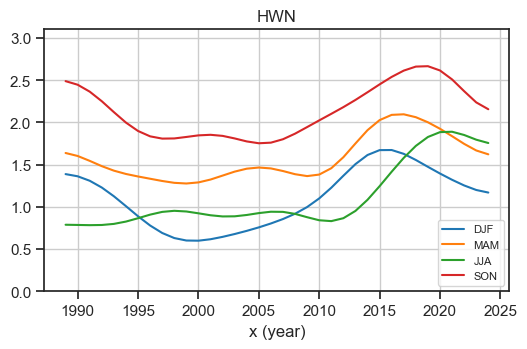

<Figure size 2000x827 with 0 Axes>

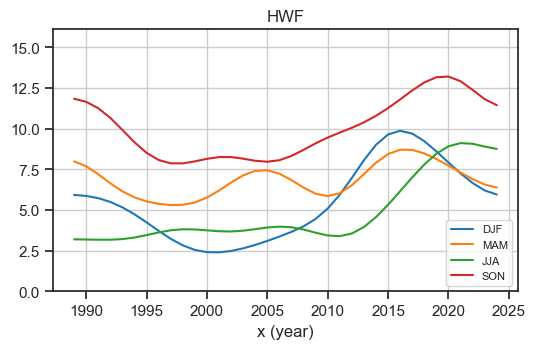

<Figure size 2000x827 with 0 Axes>

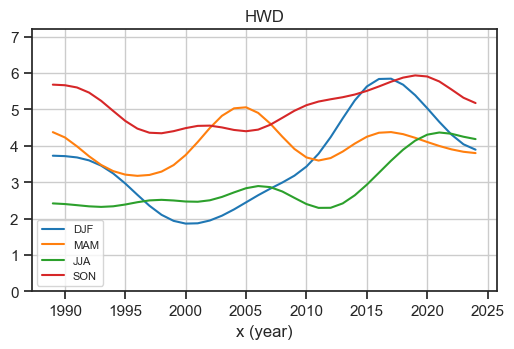

<Figure size 2000x827 with 0 Axes>

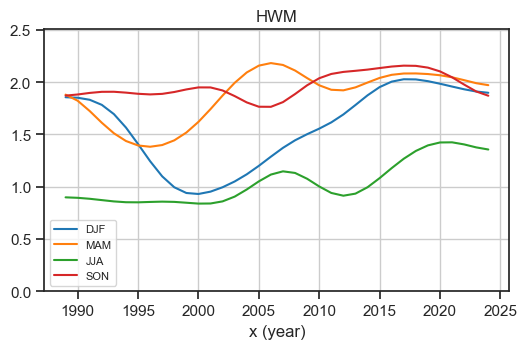

<Figure size 2000x827 with 0 Axes>

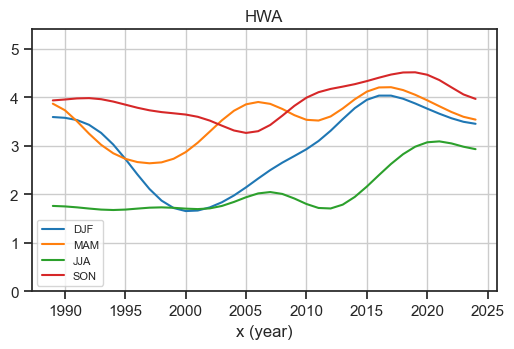

In [27]:
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

hwdef = 'MeteoChile'
hwis = ['HWN', 'HWF', 'HWD', 'HWM', 'HWA']
stat = 'mean'

#ymax = {'HWN': 15, 'HWF': 84, 'HWD': 28, 'HWM': 5, 'HWA': 15} #defined to be consistent with California ymax
#ymax = {'HWN': 5, 'HWF': 20, 'HWD': 10, 'HWM': 5, 'HWA': 15} #defined to be consistent with California ymax

ymin = {hwis[0]: 0.0, hwis[1]: 0.0, hwis[2]: 0.0, hwis[3]: 0.0, hwis[4]: 0.0}
ymax = {hwis[0]: 3.1, hwis[1]: 16.1, hwis[2]: 7.2, hwis[3]: 2.505, hwis[4]: 5.4}


#hwi = hwis[4]
statistic = 'mean'
sigma = 3

import seaborn as sns
sns.set_theme(rc={'figure.figsize':(20,8.27)})
sns.set_theme(style="ticks")
sns.set_palette("tab10")


for hwi in hwis:
    #smoothed_series = gaussian_filter(pd.to_numeric(hwi_stats_Cal[season][hwdef]['CDA'][hwi][statistic].values, errors='coerce'), sigma=sigma)
    plt.figure()
    fig, ax1 = plt.subplots(figsize=(6,3.4))

    #season = seasons[4]
    #plt.figure()
    #for hwi in hwis:
    for season in seasons[:-1]:
        smoothed_series = gaussian_filter(pd.to_numeric(hwi_stats_Cal[season][hwdef]['CDA'][hwi][statistic].values, errors='coerce'), sigma=sigma)
        #plt.plot(hwi_stats_Chile[season][hwdef]['MC'][hwi][statistic])
        ax1.plot(hwi_stats_Cal[season][hwdef]['CDA'][hwi][statistic].index, smoothed_series, label = season)
    plt.grid()
    plt.xlabel('x (year)')
    #plt.legend(seasons[:-1])
    plt.ylim([ymin[hwi], ymax[hwi]])
    plt.legend(fontsize=8)
    plt.title(hwi)


    folder = PLOTS_FOLDER
    fig.savefig(folder + 'Cal_' + hwi + '_' + 'smoothed.pdf', format='pdf')


# Plot 2: Mann-Whitney test of the previous timeseries

Note that this test is slightly different from the previous version. In the previous version we were performing a two sided test, now we are performing a one sided test to see if the next decade gives higher stats than the previous decade.

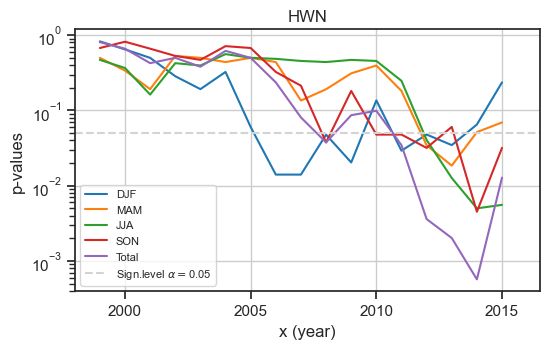

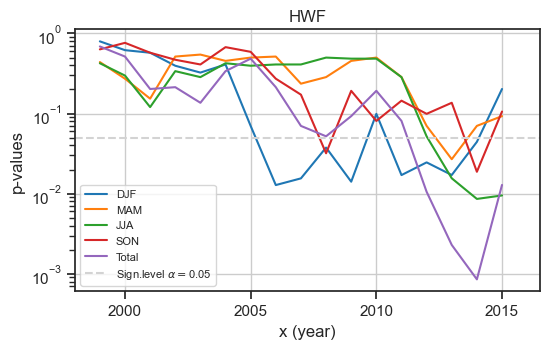

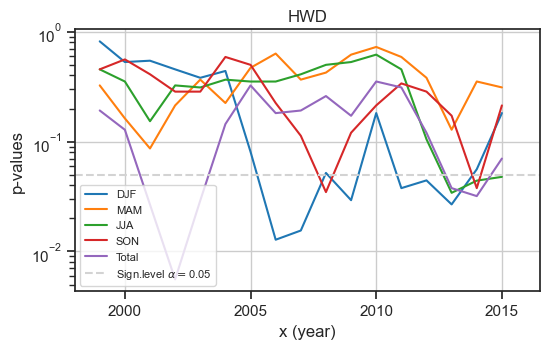

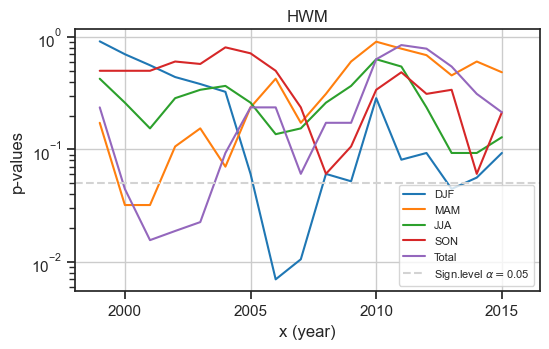

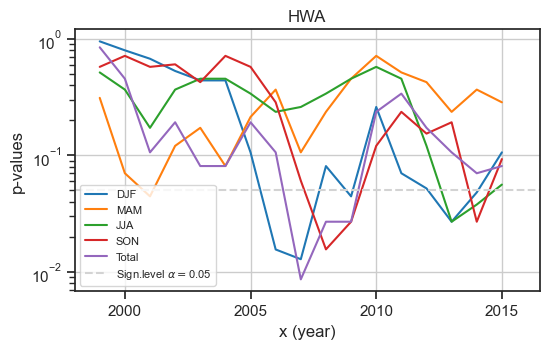

In [29]:
hwdef = 'MeteoChile'
indices = ['HWN', 'HWF', 'HWD', 'HWM', 'HWA']
#hwi = indices[4]
yw = 'CDA'
region_name = 'Cal'
meas = 'mean'

for hwi in hwis:
    hwi_stats_by_year = {}
    for season in seasons:
        hwi_stats_by_year[season] = hwi_stats_Cal[season][hwdef][yw]
        #for indice in indices:
        #    hwi_stats_by_year[season] = hwi_stats_Chile[season][hwdef][yw]

    plot_t_and_u_test_all_indices_by_season(hwi_stats_by_year, meas=meas,
                            yw = [1989, 2024], length = 10, t_or_u_plot = None, indice = hwi,
                            saveplot = True, folder = PLOTS_FOLDER, region_name = region_name,
                            test = 'u', type_test = 'one_sided', seasons = seasons[:])